In [2]:
#Cargamos el archivos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


os.chdir ('/Users/i_voo/Downloads/Ebac')

#cargamos archivo
df= pd.read_csv('vgsales.csv')

In [3]:
#Exploración básica
df. head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [5]:
df.sample(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
14896,14899,Psycho-Pass: Mandatory Happiness,PS4,2016.0,Adventure,Nippon Ichi Software,0.02,0.00,0.00,0.00,0.03
13120,13122,Arx Fatalis,XB,2003.0,Role-Playing,Mindscape,0.04,0.01,0.00,0.00,0.05
11691,11693,World Tour Soccer 06,PSP,2006.0,Sports,Sony Computer Entertainment,0.07,0.00,0.00,0.01,0.08
12745,12747,Hisshou Pachinko*Pachi-Slot Kouryaku Series Vo...,PS2,2007.0,Misc,D3Publisher,0.00,0.00,0.06,0.00,0.06
1618,1620,Guitar Hero: Aerosmith,X360,2008.0,Misc,Activision,1.00,0.14,0.00,0.10,1.23


In [6]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [8]:
#Limpieza de datos
df.isnull().sum()


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
df= df.dropna(subset=['Year', 'Publisher'])
#convertimos yeay a entero
df['Year']= df['Year'].astype(int)

In [10]:
df_numeric = df.select_dtypes(include='number')
print(df_numeric.columns)

Index(['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
       'Global_Sales'],
      dtype='object')


In [11]:
#Anañisis de totales 
#Total de viedeojuegos anaalizados
total_juegos = df['Name'].nunique()

print("Total juegos:", total_juegos)


Total juegos: 11325


In [12]:
#Total de géneros
total_generos = df['Genre'].nunique()
print("Total géneros:", total_generos)

Total géneros: 12


In [13]:
#Toatal de plataformas
total_plataformas = df['Platform'].nunique()
print("Total plataformas:", total_plataformas)

Total plataformas: 31


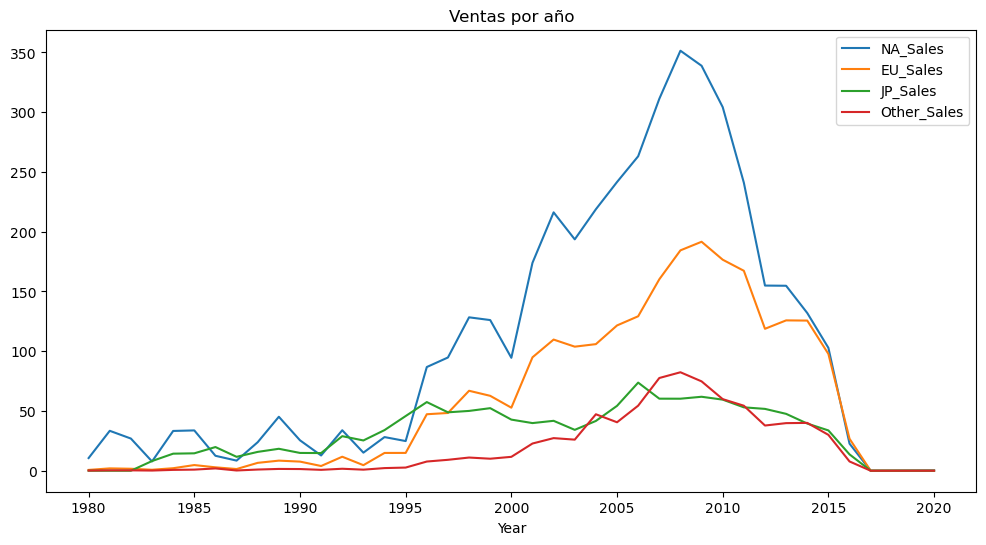

In [14]:
#VENTAS
#ventas por año
ventas_anuales = df.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

ventas_anuales.plot(figsize=(12,6))
plt.title("Ventas por año")
plt.show()


In [15]:
#Juegos más vendidos por año
top_juegos= df.loc[df.groupby('Year')['Global_Sales'].idxmax()]
print(top_juegos[['Year', 'Name', 'Global_Sales']].sort_values('Year'))

       Year                                              Name  Global_Sales
258    1980                                         Asteroids          4.31
239    1981                                          Pitfall!          4.50
89     1982                                           Pac-Man          7.81
421    1983                                          Baseball          3.20
9      1984                                         Duck Hunt         28.31
1      1985                                 Super Mario Bros.         40.24
127    1986                               The Legend of Zelda          6.51
251    1987                   Zelda II: The Adventure of Link          4.38
22     1988                               Super Mario Bros. 3         17.28
5      1989                                            Tetris         30.26
18     1990                                 Super Mario World         20.61
231    1991           The Legend of Zelda: A Link to the Past          4.61
50     1992 

In [16]:
top_juegos = df.sort_values('Global_Sales', ascending=False).groupby('Year').head(1)

top_juegos[['Year','Name','Global_Sales']].head()

,Year,Name,Global_Sales
0,2006,Wii Sports,82.74
1,1985,Super Mario Bros.,40.24
2,2008,Mario Kart Wii,35.82
3,2009,Wii Sports Resort,33.00
4,1996,Pokemon Red/Pokemon Blue,31.37


In [17]:
#Plataformas con más ingresos por año
plataformas= df.groupby(['Year', 'Platform'])['Global_Sales'].sum().reset_index()
top_plataformas = plataformas.loc[plataformas.groupby('Year')['Global_Sales'].idxmax()]

print(top_plataformas.sort_values('Year'))

     Year Platform  Global_Sales
0    1980     2600         11.38
1    1981     2600         35.77
2    1982     2600         28.86
4    1983      NES         10.96
6    1984      NES         50.09
9    1985      NES         53.44
12   1986      NES         36.41
14   1987      NES         19.76
17   1988      NES         45.01
20   1989       GB         64.98
25   1990     SNES         26.16
29   1991     SNES         16.21
35   1992     SNES         32.98
40   1993     SNES         40.01
50   1994     SNES         35.08
55   1995       PS         35.92
64   1996       PS         94.68
70   1997       PS        136.08
77   1998       PS        169.58
84   1999       PS        144.57
93   2000       PS         96.28
104  2001      PS2        166.43
113  2002      PS2        205.40
119  2003      PS2        184.29
125  2004      PS2        211.78
132  2005      PS2        160.65
143  2006      Wii        137.91
154  2007      Wii        154.97
163  2008      Wii        174.16
171  2009 

In [18]:
#Plataforma con más ingreso por año por cada región 
#Agrupamos por año y plataforma
plat_year= df.groupby(['Year', 'Platform'])[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum().reset_index()

top_plat_year = plat_year.sort_values('Global_Sales', ascending=False)\
                        .groupby('Year').head(1)

top_plat_year.head()

,Year,Platform,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
125,2004,PS2,96.78,56.01,19.17,39.85,211.78
171,2009,Wii,116.54,59.36,16.57,17.79,210.44
113,2002,PS2,96.54,65.27,21.85,21.72,205.40
119,2003,PS2,83.54,61.20,18.88,20.69,184.29
163,2008,Wii,98.77,47.36,12.69,15.25,174.16


In [19]:
# Agrupar ventas por año incluyendo TODAS las regiones + global
ventas_anuales = df.groupby('Year')[[
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales',
    'Global_Sales'
]].sum().reset_index()

# Ver resultado
ventas_anuales.head()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1980,10.59,0.67,0.00,0.12,11.38
1,1981,33.40,1.96,0.00,0.32,35.77
2,1982,26.92,1.65,0.00,0.31,28.86
3,1983,7.76,0.80,8.10,0.14,16.79
4,1984,33.28,2.10,14.27,0.70,50.36


<Figure size 1200x600 with 0 Axes>

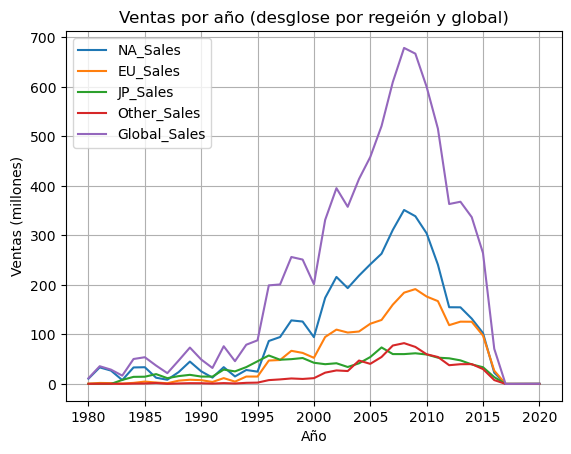

In [20]:
#OPCIONAL SOLO PARA EXPLICAR ELIMINA DESPUÉS 
plt.figure(figsize=(12,6))

ventas_anuales.set_index('Year').plot()

plt.title("Ventas por año (desglose por regeión y global)")
plt.xlabel("Año")
plt.ylabel("Ventas (millones)")
plt.grid()
plt.show()

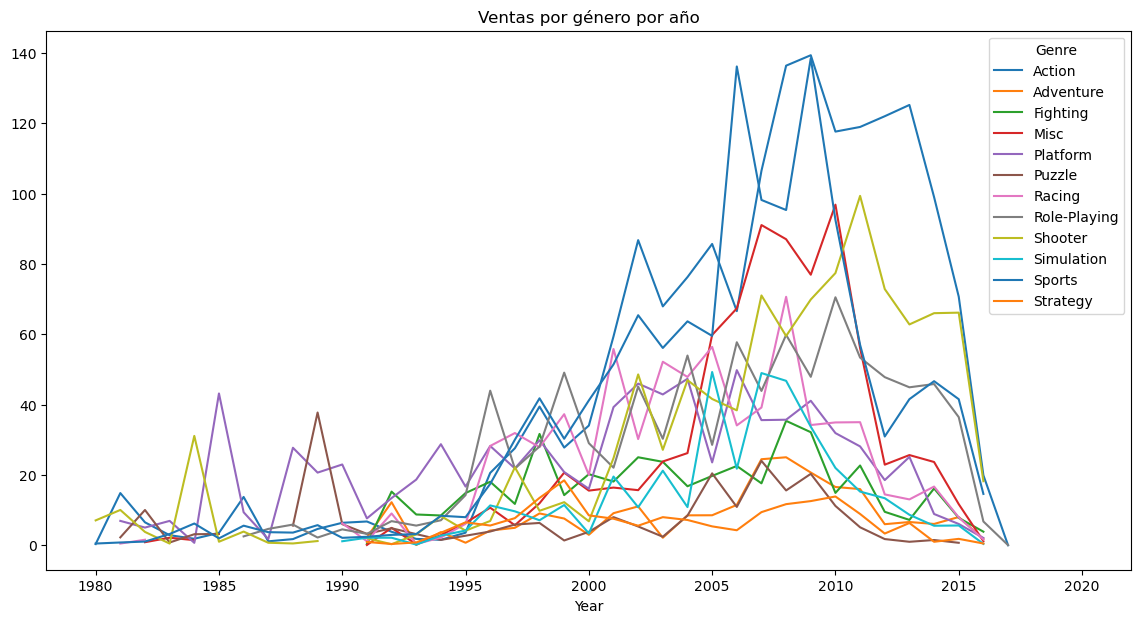

In [23]:
#Ventas de géneros por año
genero_anual = df.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack()
genero_anual.plot(figsize=(14,7))
plt.title("Ventas por género por año")
plt.show()


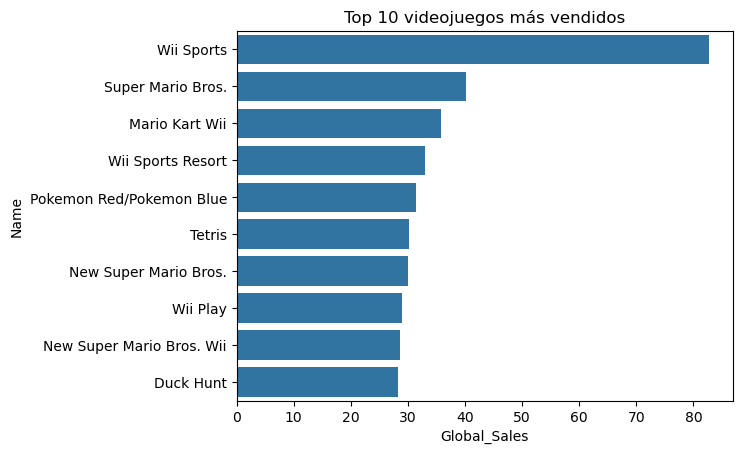

In [25]:
#Insights 
#Top 10 juegos más vendidos
top10= df.sort_values('Global_Sales', ascending=False).head(10)

sns.barplot(data=top10, x='Global_Sales', y='Name')
plt.title("Top 10 videojuegos más vendidos")
plt.show()

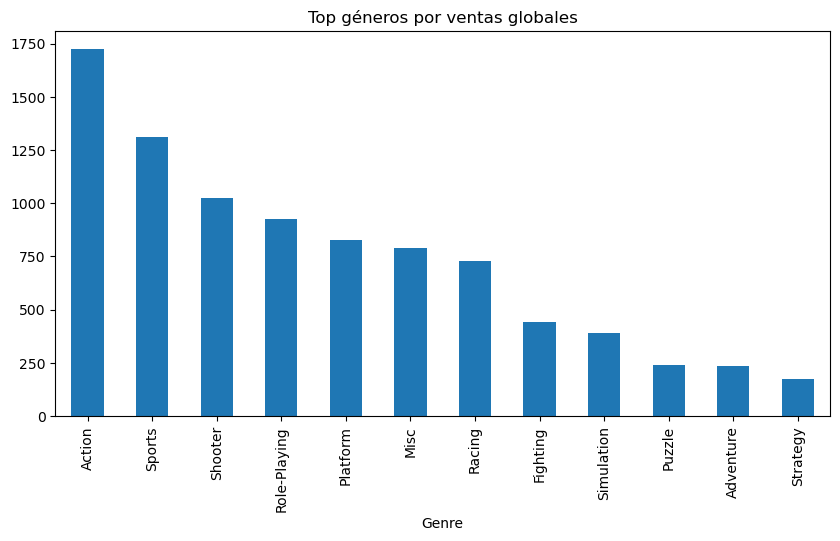

In [26]:
#Top géneros globales
top_generos= df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
top_generos.plot(kind='bar', figsize=(10,5), title='Top géneros por ventas globales')
plt.show()

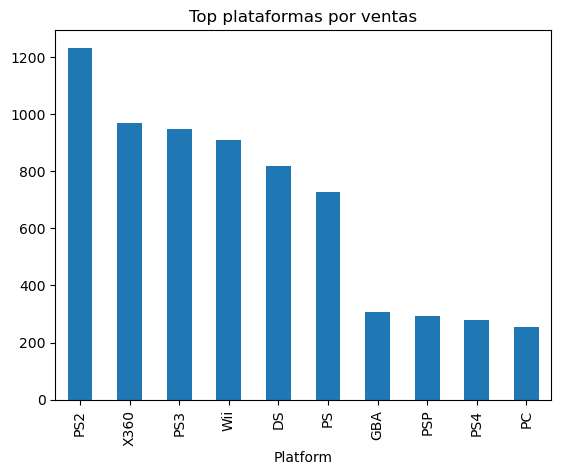

In [27]:
#Ventas por plataforma
plaforma_total=df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)
plaforma_total.head(10).plot(kind='bar')
plt.title("Top plataformas por ventas")
plt.show()

In [29]:
#Crecimiento basado en los últimos cuatro años
#Obtenemos los datos de los últimos 4 años disponobles
ultimos_4 = sorted(df['Year'].dropna().unique())[-4:]

df_4= df[df['Year'].isin(ultimos_4)]

print("Años analizados", ultimos_4)


Años analizados [2015, 2016, 2017, 2020]


In [35]:
#Crecimiento por género
#Ventas por género y año
genero = df_4.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack().fillna(0)

#Calculamos el crecimiento
crecimiento_genero= genero.loc[ultimos_4[-1]] - genero.loc[ultimos_4[0]]

#Ordenamos
crecimiento_genero= crecimiento_genero.sort_values(ascending=False)

print("Mayor crecimiento género", crecimiento_genero.idxmax())
print("Menor crecimiento género", crecimiento_genero.idxmin())

Mayor crecimiento género Puzzle
Menor crecimiento género Action


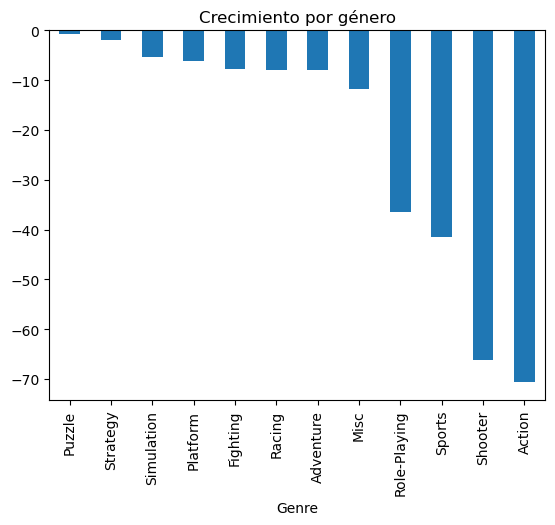

In [36]:
#Grafico de crecimiento
crecimiento_genero.plot(kind='bar', title='Crecimiento por género')
plt.show()

In [39]:
print(ultimos_4)
print(df_4.groupby('Year')['Global_Sales'].sum())

[2015, 2016, 2017, 2020]
Year
2015    264.44
2016     70.90
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64


In [40]:
#Crecimiento por plataforma
plataforma = df_4.groupby(['Year', 'Platform'])['Global_Sales'].sum().unstack().fillna(0)

#Calculamos el crecimiento
crecimiento_plat= plataforma.loc[ultimos_4[-1]] - plataforma.loc[ultimos_4[0]]

#Ordenamos
crecimiento_plat= crecimiento_plat.sort_values(ascending=False)

print("Mayor crecimiento plataforma", crecimiento_plat.idxmax())
print("Menor crecimiento plataforma", crecimiento_plat.idxmin())

Mayor crecimiento plataforma DS
Menor crecimiento plataforma PS4


In [32]:
juegos = df_4.groupby(['Year', 'Name'])['Global_Sales'].sum().unstack().fillna(0)

#Calculamos el crecimiento
crecimiento_juegos= juegos.loc[ultimos_4[-1]] - juegos.loc[ultimos_4[0]]

#Ordenamos
crecimiento_juegos= crecimiento_juegos.sort_values(ascending=False)

print("Mayor crecimiento juegos", crecimiento_juegos.idxmax())
print("Menor crecimiento juegos", crecimiento_juegos.idxmin())

Mayor crecimiento juegos Imagine: Makeup Artist
Menor crecimiento juegos Call of Duty: Black Ops 3


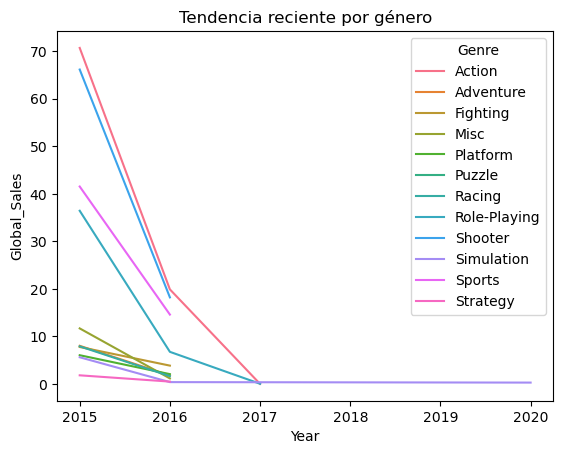

In [42]:
#Oportunidades de mercado
#Géneros en crecimiento reciente
sns.lineplot(data=df_4.groupby(['Year', 'Genre'])['Global_Sales'].sum().reset_index(),
             x='Year', y='Global_Sales', hue='Genre')
plt.title("Tendencia reciente por género")
plt.show()

In [ ]:
##Actualización del notebook